1. IMPORT THƯ VIỆN

In [57]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels pmdarima -q

In [58]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.dates as mdates
from scipy.stats import norm
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

2. ĐỌC TỆP CSV

In [59]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/retail_store_inventory.csv"
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


3. HÀM KIỂM TRA TÍNH DỪNG (ADF) & TÌM BẬC SAI PHÂN TỐI ƯU, HÀM TÍNH CHỈ SỐ WAPE

In [61]:
# Hàm kiểm tra tính dừng và tìm bậc sai phân tối ưu
def check_stationarity(series, max_diff=2):
    """
    Kiểm tra tính dừng (ADF Test) và tìm bậc sai phân d tối ưu.
    Trả về: (d_opt, p_value, is_stationary)
    """
    temp_series = series.copy().dropna()
    for d in range(max_diff + 1):
        if d > 0:
            temp_series = temp_series.diff().dropna()

        try:
            result = adfuller(temp_series)
            p_value = result[1]
            print(f"   -> Kiểm tra d={d}: ADF p-value = {p_value:.4f}")

            if p_value <= 0.05:
                print(f"      => Chuỗi dừng tại d={d}.")
                return d, p_value, True
        except:
            continue

    print("      => Cảnh báo: Chuỗi không dừng sau max_diff lần sai phân.")
    return max_diff, p_value, False

# Hàm tính chỉ số WAPE
def calculate_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

4. TIỀN XỬ LÝ DỮ LIỆU

In [62]:
# Chuyển cột Date thành datetime
df['Date'] = pd.to_datetime(df['Date'])
# Sort
df = df.sort_values(['Store ID', 'Product ID', 'Date'])
# Delete Duplicate
df = df.drop_duplicates(subset=['Store ID', 'Product ID', 'Date'])

# Xử lý thiếu dữ liệu
df['Units Sold'] = df['Units Sold'].fillna(0)
df['Inventory Level'] = df.groupby(['Store ID', 'Product ID'])['Inventory Level'].ffill()
for col in ['Price', 'Competitor Pricing', 'Discount', 'Demand Forecast']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Xử lý ngoại lệ - outlier (Winsorize P1-P99)
for col in ['Units Sold', 'Price']:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

5. CHỌN 1 CHUỖI DỮ LIỆU (Store, Product) ĐỂ CHẠY

In [63]:
# Lọc chuỗi có độ dài >= 180d
counts = df.groupby(['Store ID', 'Product ID']).size()
valid_series = counts[counts >= 180].index.tolist()

if not valid_series:
    raise ValueError("Không có chuỗi nào đủ 180 ngày dữ liệu!")

store_id, prod_id = valid_series[0] # Chọn chuỗi đầu tiên thỏa mãn
print(f"Đang xử lý chuỗi: Store {store_id} - Product {prod_id}")

data = df[(df['Store ID'] == store_id) & (df['Product ID'] == prod_id)].copy()
data = data.set_index('Date').asfreq('D') # Reindex theo ngày
data['Units Sold'] = data['Units Sold'].fillna(0)

Đang xử lý chuỗi: Store S001 - Product P0001


6. FEATURE ENGINEERING

In [64]:
# Calendar Features
data['dow'] = data.index.dayofweek
data['month'] = data.index.month
data['quarter'] = data.index.quarter
data['is_weekend'] = data['dow'].apply(lambda x: 1 if x >= 5 else 0)
data['is_month_end'] = data.index.is_month_end.astype(int)

# Interaction Features
data['Price_Discount_Interact'] = data['Price'] * data['Discount']
data['Price_Competitor_Diff'] = data['Price'] - data['Competitor Pricing']

# Lag Features
for lag in [1, 7, 14, 28]:
    data[f'lag_{lag}'] = data['Units Sold'].shift(lag)

# Rolling Features
data['rolling_mean_7'] = data['Units Sold'].shift(1).rolling(window=7).mean()

# Drop NA sinh ra do Lag/Rolling (ở phần đầu chuỗi)
data = data.dropna()

7. CHUẨN BỊ DỮ LIỆU ĐẦU VÀO & CHIA TẬP DỮ LIỆU TRAIN/VAL/TEST

In [65]:
# Định nghĩa biến
target_col = 'Units Sold'

# CHỌN BIẾN ĐẦU VÀO
# Lưu ý: 'Competitor Pricing' có thể gây VIF cao với Price, ta dùng 'Price_Competitor_Diff' thay thế hoặc giữ cả 2 nếu bắt buộc.
# Ở đây ta ưu tiên dùng Diff để giảm VIF nhưng vẫn giữ thông tin cạnh tranh.
exog_cols = [
    'Price', 'Discount', 'Holiday/Promotion',
    'Demand Forecast', # Known future covariate
    'Price_Competitor_Diff', # Thay cho raw Competitor Pricing để giảm đa cộng tuyến
    'dow', 'month', 'is_weekend', 'is_month_end'
]
cat_cols = ['Weather Condition', 'Region', 'Category'] # Biến cần OneHot

# Chia dữ liệu: Train - Val - Test (Theo thời gian, KHÔNG Shuffle)
n = len(data)
train_size = int(n * 0.7)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

train = data.iloc[:train_size]
val = data.iloc[train_size:train_size+val_size]
test = data.iloc[train_size+val_size:]

print(f"Data Split: Train={len(train)}, Val={len(val)}, Test={len(test)}")

# --- CHUẨN BỊ DỮ LIỆU ĐẦU VÀO (Fit trên mỗi tập Train) ---
# LƯU Ý: drop='first' để tránh Singular Matrix
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), exog_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    verbose_feature_names_out=False
)

# Fit (HỌC) & Transform (LÀM)
X_train = pd.DataFrame(preprocessor.fit_transform(train[exog_cols + cat_cols]), index=train.index, columns=preprocessor.get_feature_names_out())
X_val = pd.DataFrame(preprocessor.transform(val[exog_cols + cat_cols]), index=val.index, columns=preprocessor.get_feature_names_out())
X_test = pd.DataFrame(preprocessor.transform(test[exog_cols + cat_cols]), index=test.index, columns=preprocessor.get_feature_names_out())

y_train = train[target_col]
y_val = val[target_col]
y_test = test[target_col]

# Kiểm tra VIF
print("\n--- Kiểm tra Đa cộng tuyến (VIF) ---")
vif_df = pd.DataFrame()
vif_df["feature"] = X_train.columns
vif_df["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif_df.sort_values("VIF", ascending=False).head(5))

Data Split: Train=492, Val=105, Test=106

--- Kiểm tra Đa cộng tuyến (VIF) ---
               feature       VIF
7           is_weekend  2.777762
5                  dow  2.769332
13        Region_South  1.739744
12        Region_North  1.632833
16  Category_Furniture  1.615423


8. TÌM THAM SỐ TỐI ƯU VÀ KIỂM TRA TÍNH DỪNG (TUNING & STATIONARITY)

In [66]:
print("\nBắt đầu Kiểm tra Tính Dừng (Stationarity)...")
d_opt, p_val, is_stat = check_stationarity(y_train)

print("\nBắt đầu Tuning SARIMAX...")
# Tuning: (p,d,q) x (P,D,Q)s. Chọn AICc tối ưu.
model_auto = auto_arima(
    y=y_train,
    X=X_train,
    start_p=0, max_p=2,
    d=d_opt,           # Cố định d theo kết quả ADF
    start_q=0, max_q=2,
    start_P=0, max_P=2,
    D=None,            # Để auto tìm D (seasonal diff)
    start_Q=0, max_Q=2,
    m=7,               # Mùa vụ tuần s=7
    seasonal=True,
    trend=None,        # Auto detect trend
    information_criterion='aicc', # Metric chọn
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f"Best Model: {model_auto.order} x {model_auto.seasonal_order}")


Bắt đầu Kiểm tra Tính Dừng (Stationarity)...
   -> Kiểm tra d=0: ADF p-value = 0.0000
      => Chuỗi dừng tại d=0.

Bắt đầu Tuning SARIMAX...
Performing stepwise search to minimize aicc
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AICC=3533.530, Time=3.12 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AICC=3775.443, Time=6.32 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AICC=3655.161, Time=7.87 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AICC=5086.244, Time=1.24 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AICC=3764.270, Time=6.03 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AICC=3535.519, Time=6.44 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AICC=3775.032, Time=7.66 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AICC=3643.468, Time=3.30 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AICC=3535.571, Time=6.82 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AICC=inf, Time=3.73 sec

Best model:  ARIMA(0,0,0)(0,0,0)[7] intercept
Total fit time: 52.587 seconds
Best Model: (0, 0, 0) x (0, 0, 0, 7)


9. BACKTESTING (ROLLING ORIGIN VALIDATION)

In [67]:
print("\n--- Bắt đầu Backtesting (Rolling Origin, 5 Folds) ---")
tscv = TimeSeriesSplit(n_splits=5, test_size=14) # Horizon = 14
rmse_scores = []
wape_scores = []

# Gộp train + val để chạy rolling trên tập kiểm thử
full_train_val_X = pd.concat([X_train, X_val])
full_train_val_y = pd.concat([y_train, y_val])

fold = 1
for train_index, test_index in tscv.split(full_train_val_X):
    cv_X_train, cv_X_test = full_train_val_X.iloc[train_index], full_train_val_X.iloc[test_index]
    cv_y_train, cv_y_test = full_train_val_y.iloc[train_index], full_train_val_y.iloc[test_index]

    # Fit model với best order tìm được
    model = SARIMAX(
        cv_y_train,
        exog=cv_X_train,
        order=model_auto.order,
        seasonal_order=model_auto.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)

    # Forecast
    pred = res.get_forecast(steps=len(cv_y_test), exog=cv_X_test)
    y_pred_fold = pred.predicted_mean
    y_pred_fold[y_pred_fold < 0] = 0 # Post-processing: Sales >= 0

    # Score
    rmse = np.sqrt(mean_squared_error(cv_y_test, y_pred_fold))
    wape = calculate_wape(cv_y_test, y_pred_fold)

    rmse_scores.append(rmse)
    wape_scores.append(wape)
    print(f"Fold {fold}: RMSE={rmse:.3f}, WAPE={wape:.2%}")
    fold += 1

print(f"-> Average RMSE Backtest: {np.mean(rmse_scores):.3f}")
print(f"-> Average WAPE Backtest: {np.mean(wape_scores):.2%}")


--- Bắt đầu Backtesting (Rolling Origin, 5 Folds) ---
Fold 1: RMSE=39.911, WAPE=22.46%
Fold 2: RMSE=25.102, WAPE=12.63%
Fold 3: RMSE=46.300, WAPE=25.88%
Fold 4: RMSE=27.517, WAPE=20.19%
Fold 5: RMSE=26.500, WAPE=26.40%
-> Average RMSE Backtest: 33.066
-> Average WAPE Backtest: 21.51%


 10. HUẤN LUYỆN FINAL & ĐÁNH GIÁ TRÊN TEST

In [68]:
print("\n--- Final Model Training (Train + Val) -> Predict Test ---")
# Gộp train + val làm tập huấn luyện cuối cùng
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

final_model = SARIMAX(
    y_final_train,
    exog=X_final_train,
    order=model_auto.order,
    seasonal_order=model_auto.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_result = final_model.fit(disp=False)
print(final_result.summary())

# Forecast Test Set
forecast_test = final_result.get_forecast(steps=len(y_test), exog=X_test)
y_pred_test = forecast_test.predicted_mean
y_pred_test = y_pred_test.clip(lower=0) # Đảm bảo không âm
conf_int = forecast_test.conf_int()

# --- Baseline Naive-7 ---
# Lấy dữ liệu thực tế 7 ngày trước đó nối với y_test để shift
temp_series = pd.concat([y_final_train.iloc[-7:], y_test])
y_naive_7 = temp_series.shift(7).iloc[7:]

# --- Metrics Final ---
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive_7))
wape_test = calculate_wape(y_test, y_pred_test)

print(f"\n=== KẾT QUẢ CUỐI CÙNG (TEST SET) ===")
print(f"RMSE Model: {rmse_test:.3f}")
print(f"RMSE Naive-7: {rmse_naive:.3f}")
print(f"Ratio (Model/Naive): {rmse_test/rmse_naive:.2f} (Yêu cầu <= 0.85: {'ĐẠT' if rmse_test/rmse_naive <= 0.85 else 'CHƯA ĐẠT'})")
print(f"WAPE: {wape_test:.2%}")


--- Final Model Training (Train + Val) -> Predict Test ---
                               SARIMAX Results                                
Dep. Variable:             Units Sold   No. Observations:                  597
Model:                        SARIMAX   Log Likelihood               -3061.077
Date:                Mon, 08 Dec 2025   AIC                           6162.154
Time:                        14:45:15   BIC                           6249.959
Sample:                    01-29-2022   HQIC                          6196.345
                         - 09-17-2023                                         
Covariance Type:                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Price                      -2.4123      1.742     -1.385      0.166      -5.826       1.001
Discount                   -0.75

11. CHẨN ĐOÁN QC


Bắt đầu Chẩn đoán QC...
Đã lưu biểu đồ tại: plots/diagnostics_S001_P0001.png


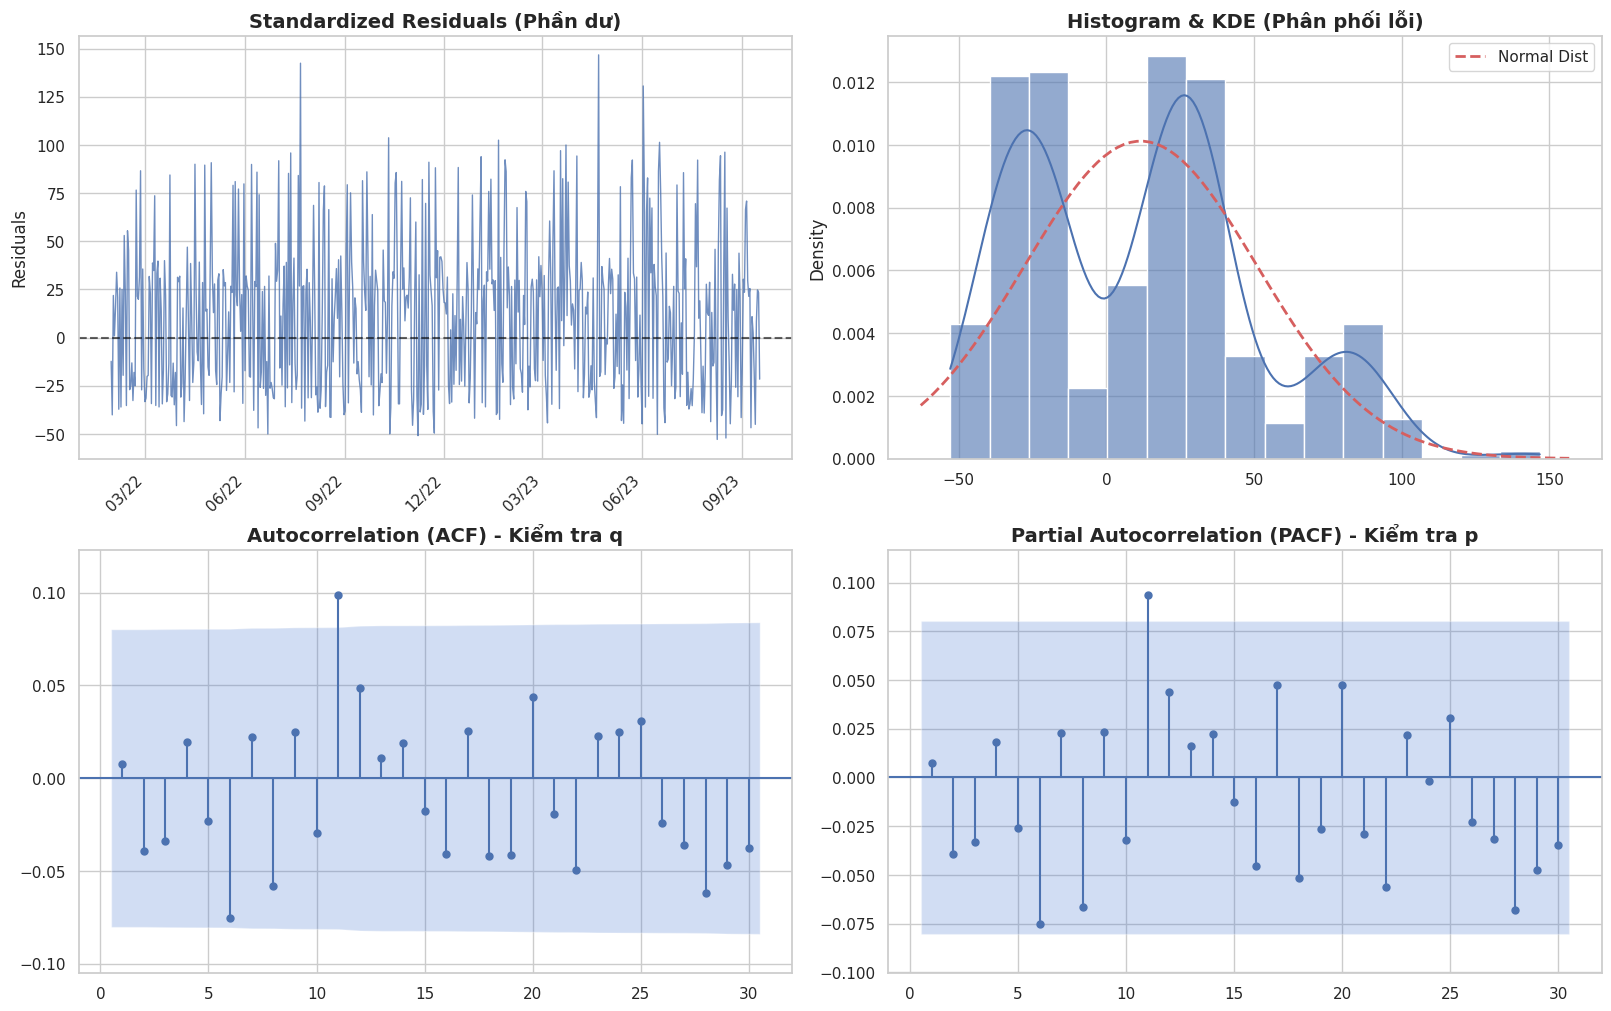


KẾT QUẢ KIỂM ĐỊNH LJUNG-BOX:
   -> p-value: 0.5432
   ĐẠT: Phần dư là nhiễu trắng (White Noise). Mô hình tốt.


In [69]:
print("\nBắt đầu Chẩn đoán QC...")

# --- TẠO THƯ MỤC TRƯỚC KHI LƯU ---
for folder in ['preds', 'plots', 'report']:
    os.makedirs(folder, exist_ok=True)

# Lấy phần dư
residuals = final_result.resid

# Cấu hình Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# A. Standardized Residuals (Phần dư theo thời gian)
ax1 = fig.add_subplot(gs[0, 0])
# Vẽ residuals với index là ngày tháng
ax1.plot(residuals.index, residuals, color='#4c72b0', alpha=0.8, linewidth=1)
ax1.axhline(0, linestyle='--', color='black', alpha=0.6, linewidth=1.5)
ax1.set_title('Standardized Residuals (Phần dư)', fontweight='bold')
ax1.set_ylabel('Residuals')

# Chỉ hiện mốc thời gian mỗi 3 tháng (interval=3)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
# Định dạng hiển thị: Tháng/Năm (ví dụ: 08/22)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%y'))
# Xoay chữ 45 độ để không đè lên nhau
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# B. Histogram & KDE vs Normal Distribution
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(residuals, kde=True, ax=ax2, color='#4c72b0', stat='density', edgecolor='white', alpha=0.6)
mu, std = norm.fit(residuals)
xmin, xmax = ax2.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
ax2.plot(x, p, 'r--', linewidth=2, label='Normal Dist')
ax2.set_title('Histogram & KDE (Phân phối lỗi)', fontweight='bold')
ax2.legend()

# C. Autocorrelation (ACF)
ax3 = fig.add_subplot(gs[1, 0])
plot_acf(residuals, lags=30, ax=ax3, zero=False, auto_ylims=True,
         title='Autocorrelation (ACF)', color='#4c72b0', vlines_kwargs={"colors": "#4c72b0"})
ax3.set_title('Autocorrelation (ACF) - Kiểm tra q', fontweight='bold')

# D. Partial Autocorrelation (PACF)
ax4 = fig.add_subplot(gs[1, 1])
plot_pacf(residuals, lags=30, ax=ax4, zero=False, auto_ylims=True,
          title='Partial Autocorrelation (PACF)', color='#4c72b0', vlines_kwargs={"colors": "#4c72b0"})
ax4.set_title('Partial Autocorrelation (PACF) - Kiểm tra p', fontweight='bold')

# Lưu file ảnh
diag_filename = f"plots/diagnostics_{store_id}_{prod_id}.png"
plt.savefig(diag_filename, dpi=300, bbox_inches='tight')
print(f"Đã lưu biểu đồ tại: {diag_filename}")

plt.show()

# Kiểm định Ljung-Box
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
lb_pvalue = lb_test['lb_pvalue'].values[0]
print(f"\nKẾT QUẢ KIỂM ĐỊNH LJUNG-BOX:")
print(f"   -> p-value: {lb_pvalue:.4f}")
if lb_pvalue > 0.05:
    print("   ĐẠT: Phần dư là nhiễu trắng (White Noise). Mô hình tốt.")
else:
    print("   CẢNH BÁO: Phần dư vẫn còn quy luật (p < 0.05). Cần xem lại tham số.")

12. DELIVERABLES


--- BẮT ĐẦU QUÁ TRÌNH BÀN GIAO (DELIVERABLES) ---
[1/3] Đã xuất file CSV: preds/sarimax_S001_P0001.csv
[2/3] Đã lưu Biểu đồ Dự báo: plots/actual_vs_pred_S001_P0001.png


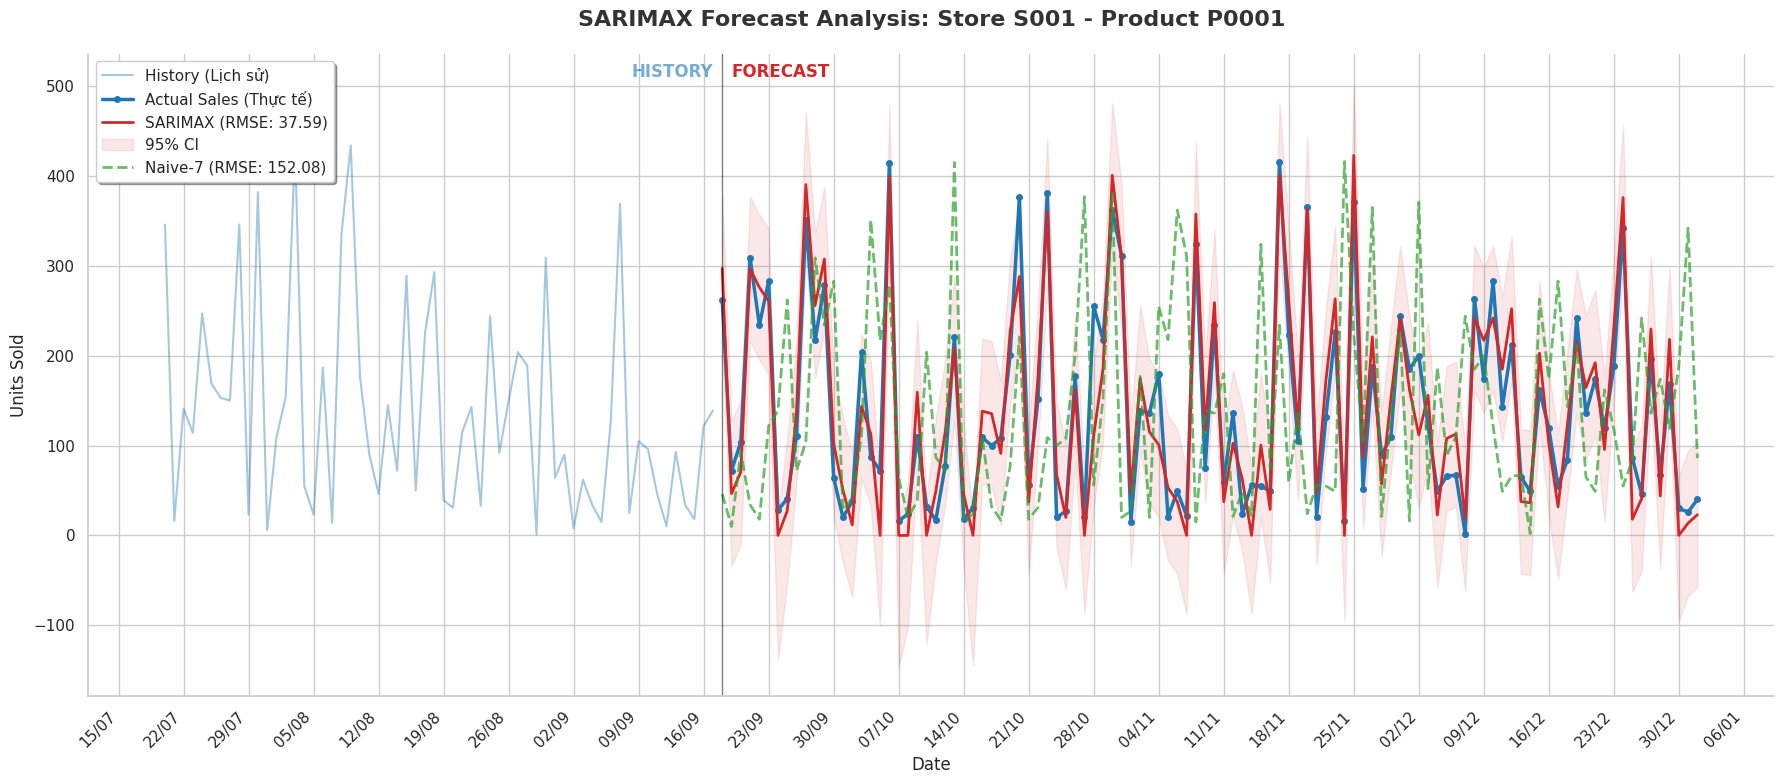

[3/3] Đã tạo Báo cáo chi tiết: report/SARIMAX_S001_P0001.md


In [ ]:
print("\n--- BẮT ĐẦU QUÁ TRÌNH BÀN GIAO (DELIVERABLES) ---")

# --- 1. Chuẩn bị số liệu cho Báo cáo ---
# A. Tính Ljung-Box p-value
residuals = final_result.resid
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
lb_pvalue = lb_test['lb_pvalue'].values[0]

# B. Tính VIF (Đa cộng tuyến)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_table = vif_data.sort_values("VIF", ascending=False).to_markdown(index=False, floatfmt=".2f")

# --- 2. XUẤT FILE DỮ LIỆU (CSV) ---
output_df = pd.DataFrame({
    'date': y_test.index,
    'y_true': y_test,
    'y_pred': y_pred_test,
    'lo': conf_int.iloc[:,0],
    'hi': conf_int.iloc[:,1]
})
csv_filename = f"preds/sarimax_{store_id}_{prod_id}.csv"
output_df.to_csv(csv_filename)
print(f"[1/3] Đã xuất file CSV: {csv_filename}")

# --- 3. VẼ BIỂU ĐỒ DỰ BÁO (MAIN PLOT) ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (18, 8)

# Lấy dữ liệu lịch sử (60 ngày)
history_window = 60
history_data = y_final_train.iloc[-history_window:]

fig, ax = plt.subplots()

# A. Vẽ các đường
ax.plot(history_data.index, history_data, label='History (Lịch sử)', color='tab:blue', alpha=0.4, linewidth=1.5)
ax.plot(y_test.index, y_test, label='Actual Sales (Thực tế)', color='tab:blue', linewidth=2.5, marker='o', markersize=4)
ax.plot(y_test.index, y_pred_test, label=f'SARIMAX (RMSE: {rmse_test:.2f})', color='tab:red', linestyle='-', linewidth=2)
ax.fill_between(y_test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='tab:red', alpha=0.1, label='95% CI')
ax.plot(y_test.index, y_naive_7, label=f'Naive-7 (RMSE: {rmse_naive:.2f})', color='tab:green', linestyle='--', linewidth=2, alpha=0.7)

# B. Trang trí & Phân vùng
forecast_start_date = y_test.index[0]
ax.axvline(forecast_start_date, color='black', linestyle='-', linewidth=1, alpha=0.5)
ylim_top = ax.get_ylim()[1]
ax.text(forecast_start_date - pd.Timedelta(days=1), ylim_top*0.98, 'HISTORY', ha='right', va='top', color='tab:blue', fontweight='bold', alpha=0.6)
ax.text(forecast_start_date + pd.Timedelta(days=1), ylim_top*0.98, 'FORECAST', ha='left', va='top', color='tab:red', fontweight='bold')

# C. Sửa lỗi hiển thị ngày
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7)) # Giãn cách 7 ngày
plt.xticks(rotation=45, ha='right', fontsize=11)

# D. Hoàn thiện
ax.set_title(f"SARIMAX Forecast Analysis: Store {store_id} - Product {prod_id}", fontsize=16, fontweight='bold', pad=20, color='#333333')
ax.set_ylabel("Units Sold")
ax.set_xlabel("Date")
ax.legend(loc='upper left', frameon=True, shadow=True)
sns.despine(top=True, right=True)

plt.tight_layout()
plot_filename = f"plots/actual_vs_pred_{store_id}_{prod_id}.png"
plt.savefig(plot_filename, dpi=300)
print(f"[2/3] Đã lưu Biểu đồ Dự báo: {plot_filename}")
plt.show()

# --- 4. TẠO BÁO CÁO ---
# Lấy hệ số quan trọng
params = final_result.params
significant_params = params[abs(params) > 0.001].sort_values(ascending=False).to_markdown(floatfmt=".4f")

# Đánh giá trạng thái
status = "ĐẠT YÊU CẦU" if rmse_test/rmse_naive <= 0.85 else "CHƯA ĐẠT YÊU CẦU"
lb_status = "Phần dư ngẫu nhiên (Tốt)" if lb_pvalue > 0.05 else "Phần dư còn quy luật (Cần cải thiện)"

report_content = f"""# 📊 Báo Cáo Kết Quả Mô Hình SARIMAX
**Store:** {store_id} | **Product:** {prod_id}

---

## 1. Đánh giá Hiệu suất (Performance)

| Metric | SARIMAX (Model) | Naive-7 (Baseline) | Kết quả |
| :--- | :--- | :--- | :--- |
| **RMSE** | **{rmse_test:.3f}** | {rmse_naive:.3f} | Ratio: **{rmse_test/rmse_naive:.2f}** (Target ≤ 0.85) |
| **WAPE** | **{wape_test:.2%}** | - | Kỳ vọng: 10-20% |

**Kết luận:** {status}

---

## 2. Thông số Kỹ thuật
* **Model Order:** {model_auto.order} x {model_auto.seasonal_order} (m=7)
* **Thông tin AIC:** {final_result.aic:.2f}

---

## 3. Các Yếu tố Ảnh hưởng Chính (Key Drivers)
*Các biến số có trọng số lớn nhất trong việc dự báo:*

{significant_params}

---

## 4. Kết quả Kiểm tra Chất lượng (QC Summary)

### A. Kiểm định Nhiễu trắng (Residuals)
* **Ljung-Box p-value:** `{lb_pvalue:.4f}`
* **Đánh giá:** {lb_status}

### B. Kiểm tra Đa cộng tuyến (VIF)
*Bảng dưới đây liệt kê mức độ tương quan giữa các biến (Yêu cầu VIF < 10)*:

{vif_table}

---
*Báo cáo được tạo tự động vào ngày {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}*
"""

md_filename = f"report/SARIMAX_{store_id}_{prod_id}.md"
with open(md_filename, "w", encoding='utf-8') as f:
    f.write(report_content)
print(f"[3/3] Đã tạo Báo cáo chi tiết: {md_filename}")